# KRAS: учимся сравнивать две группы

Этот ноутбук объясняет, что берём, что сравниваем и как интерпретировать результат. Запускайте ячейки сверху вниз. Исходный `simpleHypo_analys.ipynb` остаётся вашим черновиком.

**Вопрос:** различается ли средний эффект нокаута KRAS между линиями с зарегистрированным hotspot KRAS и линиями без такого hotspot?

Одна строка — клеточная модель. Ответ — KRAS Gene Effect: более отрицательная оценка соответствует более сильному снижению роста/жизнеспособности. Это не вероятность смерти клетки. Экспрессия пока не участвует в сравнении: её добавим, когда перейдём к прогнозированию.

Путь анализа: проверить данные → описать группы → увидеть распределения → оценить разность средних → выполнить тест → проверить устойчивость к родству линий и определению группы → сформулировать ограниченный вывод.

## 1. Загружаем данные и инструменты

**Зачем:** сделать анализ воспроизводимым из сохранённого CSV без переменных другого ноутбука. pandas работает с таблицами, NumPy — с числами, SciPy — с распределениями и тестами, matplotlib — с графиками.

При необходимости установите зависимости в выбранное ядро: `%pip install pandas numpy scipy matplotlib`. Ячейка ниже поддерживает запуск из папки pilot или корня проекта.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display

candidates = [Path.cwd(), Path.cwd() / "data" / "pilot"]
pilot_dir = next((p for p in candidates if (p / "KRAS_data.csv").exists()), None)
if pilot_dir is None:
    raise FileNotFoundError("Запустите ноутбук из data/pilot или корня проекта")

raw = pd.read_csv(pilot_dir / "KRAS_data.csv")
models = pd.read_csv(pilot_dir.parent / "COAD_Model.csv")
print("Файл:", pilot_dir / "KRAS_data.csv")
print("Python:", sys.version.split()[0], "| pandas:", pd.__version__, "| scipy:", scipy.__version__)
print("Размер:", raw.shape)
display(raw.head())

Matplotlib is building the font cache; this may take a moment.


Файл: /Users/nident/Desktop/JOB/Cancer Cell Line Encyclopedia (CCLE)/data/pilot/KRAS_data.csv
Python: 3.13.13 | pandas: 3.0.5 | scipy: 1.18.1
Размер: (46, 5)


,ModelID,KRAS_GeneEffect,KRAS_expression,KRAS_protein_changes,KRAS_hotspot
0,ACH-000552,-0.468224,4.958708,NaN,0
1,ACH-000958,-0.526112,4.672029,NaN,0
2,ACH-001061,-1.514492,5.191002,p.G13D,1
3,ACH-002669,-0.349134,4.760817,NaN,0
4,ACH-000403,-2.140278,4.167262,p.G13D,1


## 2. Проверяем, что именно означают группы

**Зачем:** статистический тест не исправляет неверное определение групп.

- `KRAS_hotspot = 1`: в выбранном профиле зарегистрирован хотя бы один hotspot-вариант KRAS.
- `KRAS_hotspot = 0`: hotspot не найден. Это может быть линия с другой мутацией KRAS.
- Пропуск: статус неизвестен; такую строку нельзя автоматически включить в группу 0.

Поэтому названия «with Mutation» и «without Mutation» заменяем на «с hotspot» и «без hotspot». Для надёжности сверяем флаг с исходной таблицей вариантов. Отсутствие записей мутаций вообще оставляем неизвестным; если у KRAS есть неизвестные hotspot-аннотации и нет подтверждённого hotspot, статус также неизвестен.

In [2]:
assert raw["ModelID"].notna().all() and raw["ModelID"].is_unique
assert raw["KRAS_hotspot"].dropna().isin([0, 1]).all()

mut = pd.read_csv(
    pilot_dir.parent / "COAD_Mutations.csv",
    usecols=["ModelID", "IsDefaultEntryForModel", "HugoSymbol", "Hotspot"],
    low_memory=False
)
mut = mut.loc[mut["IsDefaultEntryForModel"].eq("Yes")].copy()
kras = mut.loc[mut["HugoSymbol"].eq("KRAS")].copy()
kras["hotspot_flag"] = (
    kras["Hotspot"].astype("string").str.strip().str.lower()
    .map({"true": True, "false": False}).astype("boolean")
)
positive_ids = kras.loc[kras["hotspot_flag"].fillna(False), "ModelID"]
unknown_ids = kras.loc[kras["hotspot_flag"].isna(), "ModelID"]

data = raw.merge(
    models[["ModelID", "CellLineName", "PatientID"]],
    on="ModelID", how="left", validate="one_to_one"
)
expected = data["ModelID"].isin(positive_ids).astype("Int64")
unknown = (
    ~data["ModelID"].isin(mut["ModelID"])
    | (data["ModelID"].isin(unknown_ids) & ~data["ModelID"].isin(positive_ids))
)
expected.loc[unknown] = pd.NA
old = data["KRAS_hotspot"].astype("Int64")
changed = (old.fillna(-1) != expected.fillna(-1)).sum()
print("Исправлено статусов после сверки:", changed)
data["KRAS_hotspot"] = expected
data["has_KRAS_variant_record"] = data["ModelID"].isin(kras["ModelID"])

eligible = data["KRAS_hotspot"].notna() & data["KRAS_GeneEffect"].notna()
print("Исключено строк с неизвестным статусом или y:", int((~eligible).sum()))
analysis = data.loc[eligible].copy()
assert np.isfinite(analysis["KRAS_GeneEffect"]).all()
analysis["group"] = analysis["KRAS_hotspot"].map({1: "С hotspot", 0: "Без hotspot"})
display(analysis.groupby("group")["has_KRAS_variant_record"].agg(["size", "sum"]))

Исправлено статусов после сверки: 0
Исключено строк с неизвестным статусом или y: 0


,size,sum
group,,
Без hotspot,23,1
С hotspot,23,23


## 3. Проверяем независимость наблюдений

**Зачем:** стандартные двухвыборочные t-тесты предполагают независимые наблюдения. Две линии одного пациента могут быть похожи из-за общего происхождения; это не две полностью независимые реплики.

Добавляем PatientID только для проверки структуры данных, не как числовой признак. Для неизвестного PatientID используем отдельную техническую группу, но это не доказывает независимость. Основной расчёт по всем строкам будет предварительным. Ниже повторим его, выбирая одну линию на пациента.

In [3]:
analysis["patient_group"] = analysis["PatientID"].fillna(analysis["ModelID"])
related = analysis.loc[analysis["patient_group"].duplicated(keep=False)]
print("Линий:", len(analysis))
print("Групп PatientID:", analysis["patient_group"].nunique())
print("Неизвестный PatientID:", analysis["PatientID"].isna().sum())
display(related[["ModelID", "CellLineName", "PatientID", "group", "KRAS_GeneEffect"]])

Линий: 46
Групп PatientID: 45
Неизвестный PatientID: 0


,ModelID,CellLineName,PatientID,group,KRAS_GeneEffect
2,ACH-001061,DLD-1,PT-i0VYNQ,С hotspot,-1.514492
38,ACH-000997,HCT-15,PT-i0VYNQ,С hotspot,-0.699265


## 4. Описываем данные до теста

**Зачем:** понять величину различия и разброс, а не начинать с одного p-value.

- count — число линий;
- mean — среднее, которое сравнивает t-тест;
- std — стандартное отклонение отдельных наблюдений;
- 50% — медиана; 25% и 75% — границы средней половины наблюдений;
- min/max — крайние значения.

Обозначим разность как **среднее с hotspot минус среднее без hotspot**. Отрицательное число поддерживает ожидаемое направление. Разность измеряется в единицах Gene Effect; делить эти отрицательные средние для вывода «во столько раз смертельнее» нельзя.

In [4]:
with_hotspot = analysis.loc[analysis["KRAS_hotspot"].eq(1), "KRAS_GeneEffect"]
without_hotspot = analysis.loc[analysis["KRAS_hotspot"].eq(0), "KRAS_GeneEffect"]
assert min(len(with_hotspot), len(without_hotspot)) >= 2
display(analysis.groupby("group")["KRAS_GeneEffect"].describe())
difference = with_hotspot.mean() - without_hotspot.mean()
variance_ratio = with_hotspot.var(ddof=1) / without_hotspot.var(ddof=1)
print(f"Разность средних: {difference:.3f}")
print(f"Отношение выборочных дисперсий: {variance_ratio:.2f}")

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
Без hotspot,23.0,-0.715637,0.386795,-1.558605,-0.993873,-0.711538,-0.494847,0.025491
С hotspot,23.0,-1.951581,0.730169,-3.237185,-2.521762,-1.949217,-1.441274,-0.699265


Разность средних: -1.236
Отношение выборочных дисперсий: 3.56


## 5. Рисуем каждую линию

**Зачем:** увидеть перекрытие групп, асимметрию и крайние наблюдения. Столбики только со средними скрыли бы эту информацию.

Каждая точка — линия; случайное небольшое смещение по горизонтали только разделяет точки, не меняет Gene Effect. Коробка показывает квартили, линия внутри — медиану. Ноль служит ориентиром шкалы, а не границей доказанной летальности.

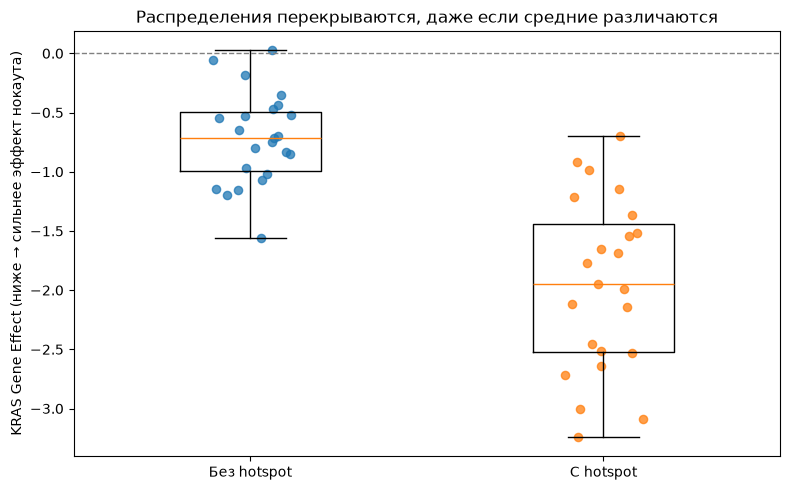

In [5]:
rng = np.random.default_rng(42)
fig, ax = plt.subplots(figsize=(8, 5))
arrays = [without_hotspot.to_numpy(), with_hotspot.to_numpy()]
ax.boxplot(arrays, positions=[0, 1], widths=0.4, showfliers=False)
for position, values in enumerate(arrays):
    ax.scatter(position + rng.uniform(-0.12, 0.12, len(values)), values,
               alpha=0.75, s=35)
ax.set_xticks([0, 1], ["Без hotspot", "С hotspot"])
ax.set_ylabel("KRAS Gene Effect (ниже → сильнее эффект нокаута)")
ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.set_title("Распределения перекрываются, даже если средние различаются")
fig.tight_layout()
plt.show()

## 6. Что проверяет t-тест

**Нулевая гипотеза H₀:** средние Gene Effect в двух группах равны. **Альтернатива H₁:** средние различаются.

Используем двусторонний тест: он допускает различие в любом направлении. Ожидаем отрицательную разность, но не переключаем тест на односторонний после просмотра результата.

p-value — вероятность при H₀ и предпосылках теста получить столь же или более экстремальную t-статистику. Это **не** вероятность истинности H₀, не вероятность случайности всего исследования и не вероятность успешного предсказания.

Порог 0.05 — соглашение для решения, а не граница биологической важности. Здесь сравнение заранее одно; если начать тестировать множество генов и вариантов, понадобится учитывать множественные проверки.

## 7. Почему Уэлч, а не обычный тест Стюдента

Здесь «тест Стюдента» означает двухвыборочный тест с объединённой оценкой дисперсии. Уэлч тоже относится к семейству t-тестов.

| Свойство | Стюдент | Уэлч |
|---|---|---|
| Что сравнивает | Средние | Средние |
| Равенство дисперсий популяций | Предполагается | Не требуется |
| Независимость наблюдений | Требуется | Требуется |
| Степени свободы | n₁ + n₀ − 2 | Рассчитываются по размерам и дисперсиям групп |

В ваших исходных сводках std примерно 0.73 и 0.39; дисперсии отличаются примерно в 3.6 раза. Это описательный факт, не доказательство неравенства дисперсий популяций. Но равенство дисперсий нам не обосновано, поэтому выбираем Уэлча без лишнего предположения. Не нужно сначала проводить тест равенства дисперсий и по его p-value переключать метод.

**Нюанс:** при равных размерах групп t-статистика Стюдента и Уэлча совпадает. Различаются степени свободы и p-value. Поэтому Стюдент здесь не обязательно даст противоположный вывод.

Уэлч не исправляет зависимость родственных линий, ошибки данных или сильные выбросы. Обоснование t-распределения связано с нормальностью наблюдений; при умеренных размерах выборки тест часто применяют приближённо. При 23 строках графики важны. Q–Q-график ниже — диагностика формы, не автоматическое разрешение или запрет на тест.

[Документация SciPy: equal_var=True / False](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html).

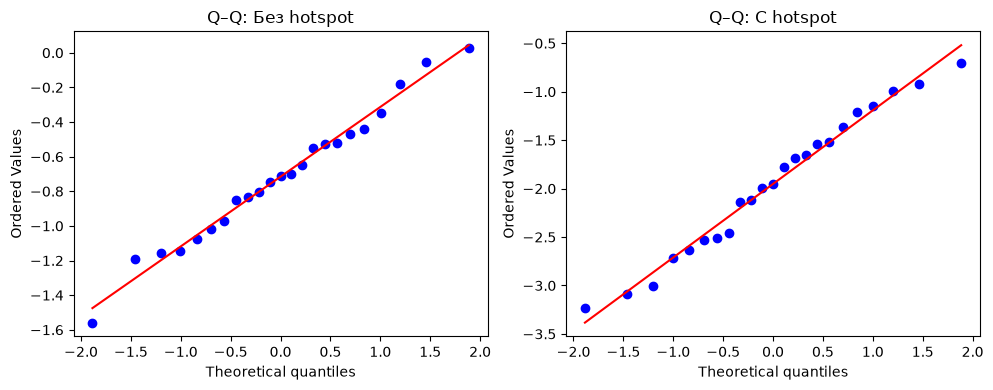

,Тест,t,df,p_value
0,Стюдент,-7.17347,44.00000,6.370910e-09
1,Уэлч,-7.17347,33.44584,2.962842e-08


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, values, title in zip(axes, arrays, ["Без hotspot", "С hotspot"]):
    stats.probplot(values, dist="norm", plot=ax)
    ax.set_title("Q–Q: " + title)
fig.tight_layout()
plt.show()

student = stats.ttest_ind(with_hotspot, without_hotspot, equal_var=True)
welch = stats.ttest_ind(with_hotspot, without_hotspot, equal_var=False)
display(pd.DataFrame({
    "Тест": ["Стюдент", "Уэлч"],
    "t": [student.statistic, welch.statistic],
    "df": [student.df, welch.df],
    "p_value": [student.pvalue, welch.pvalue]
}))

## 8. Собираем расчёт Уэлча по частям

**Зачем:** понять, откуда берутся t, p-value и доверительный интервал.

1. Считаем средние и разность Δ.
2. Считаем выборочные дисперсии s² с ddof=1 (деление на n−1).
3. Делим дисперсию на n: получаем оценку дисперсии среднего. Больше независимых наблюдений — точнее среднее.
4. Складываем дисперсии двух средних и берём корень: SE = √(s₁²/n₁ + s₀²/n₀). **SE — неопределённость разности**, std — разброс отдельных линий.
5. t = Δ/SE: сколько стандартных ошибок отделяет наблюдаемую разность от нуля.
6. Степени свободы по формуле Уэлча–Саттертуэйта выбирают подходящее t-распределение; они могут быть дробными.
7. По двум хвостам распределения получаем p-value.
8. Строим 95%-й интервал: Δ ± критическое значение t × SE. Он показывает диапазон разностей, совместимых с данными при предпосылках метода.

Частотная трактовка 95%: при многократном повторении корректной процедуры около 95% таких интервалов накрывали бы истинную разность. Это не интервал для 95% отдельных клеточных линий.

In [7]:
n1, n0 = len(with_hotspot), len(without_hotspot)
mean1, mean0 = with_hotspot.mean(), without_hotspot.mean()
s1_squared, s0_squared = with_hotspot.var(ddof=1), without_hotspot.var(ddof=1)
v1, v0 = s1_squared / n1, s0_squared / n0
delta = mean1 - mean0
se = np.sqrt(v1 + v0)
t_manual = delta / se
df_manual = (v1 + v0)**2 / (v1**2 / (n1 - 1) + v0**2 / (n0 - 1))
p_manual = 2 * stats.t.sf(abs(t_manual), df=df_manual)
critical = stats.t.ppf(0.975, df=df_manual)
ci_low, ci_high = delta - critical * se, delta + critical * se

display(pd.Series({
    "Разность средних": delta, "Стандартная ошибка SE": se,
    "t": t_manual, "df": df_manual, "p-value": p_manual,
    "Нижняя граница 95% ДИ": ci_low, "Верхняя граница 95% ДИ": ci_high
}))
np.testing.assert_allclose(t_manual, welch.statistic)
np.testing.assert_allclose(p_manual, welch.pvalue)
print("Ручной расчёт совпадает со SciPy.")

Разность средних         -1.235944e+00
Стандартная ошибка SE     1.722937e-01
t                        -7.173470e+00
df                        3.344584e+01
p-value                   2.962842e-08
Нижняя граница 95% ДИ    -1.586300e+00
Верхняя граница 95% ДИ   -8.855868e-01
dtype: float64

Ручной расчёт совпадает со SciPy.


## 9. Проверяем влияние родственных линий

**Зачем:** HCT-15 и DLD-1 имеют общий PatientID. Предварительный тест по 46 строкам этого не учитывает.

Простая учебная проверка: оставить по одной линии на пациента. Правило выбираем без просмотра Gene Effect — минимальный ModelID. Затем пробуем максимальный ModelID. Мы показываем оба результата, не выбираем тот, где p-value меньше.

Это уменьшает повторный учёт одного пациента, но не гарантирует отсутствие других зависимостей или смешивающих факторов. Для развитого анализа можно использовать модели, учитывающие группы пациентов.

In [8]:
def compare_groups(frame, label):
    a = frame.loc[frame["KRAS_hotspot"].eq(1), "KRAS_GeneEffect"]
    b = frame.loc[frame["KRAS_hotspot"].eq(0), "KRAS_GeneEffect"]
    if min(len(a), len(b)) < 2:
        raise ValueError("Для расчёта нужно минимум два наблюдения в каждой группе")
    result = stats.ttest_ind(a, b, equal_var=False)
    ci = result.confidence_interval(confidence_level=0.95)
    return {
        "Сценарий": label, "n_hotspot": len(a), "n_no_hotspot": len(b),
        "Разность": a.mean() - b.mean(),
        "CI_low": ci.low, "CI_high": ci.high, "p_value": result.pvalue
    }

ordered = analysis.sort_values("ModelID")
one_per_patient = ordered.drop_duplicates("patient_group", keep="first")
alternative_patient = ordered.drop_duplicates("patient_group", keep="last")
sensitivity = pd.DataFrame([
    compare_groups(analysis, "Все линии: предварительно"),
    compare_groups(one_per_patient, "Одна на пациента: min ModelID"),
    compare_groups(alternative_patient, "Одна на пациента: max ModelID")
])
display(sensitivity)

,Сценарий,n_hotspot,n_no_hotspot,Разность,CI_low,CI_high,p_value
0,Все линии: предварительно,23,23,-1.235944,-1.586300,-0.885587,2.962842e-08
1,Одна на пациента: min ModelID,22,23,-1.255811,-1.617402,-0.894221,5.579652e-08
2,Одна на пациента: max ModelID,22,23,-1.292867,-1.635546,-0.950188,8.290165e-09


## 10. Проверяем определение группы «без hotspot»

**Зачем:** исходная биологическая идея сравнивала hotspot с отсутствием зарегистрированного варианта KRAS. Но нулевой hotspot также включает другие варианты.

Покажем такие линии и повторим анализ без них, снова с одной линией на пациента. Это анализ чувствительности с несколько другой группой сравнения. Нельзя незаметно заменить им основной результат только потому, что p-value стало удобнее.

Отсутствие зарегистрированного варианта по-прежнему не доказывает wild-type: для этого нужна дополнительная информация о покрытии/анализе.

In [9]:
other_variants = analysis["KRAS_hotspot"].eq(0) & analysis["has_KRAS_variant_record"]
display(analysis.loc[other_variants, [
    "ModelID", "CellLineName", "KRAS_protein_changes", "KRAS_GeneEffect"
]])
strict = (
    analysis.loc[~other_variants].sort_values("ModelID")
    .drop_duplicates("patient_group", keep="first")
)
display(pd.DataFrame([
    compare_groups(one_per_patient, "Без hotspot: включает другие варианты"),
    compare_groups(strict, "Без любых зарегистрированных вариантов KRAS")
]))

,ModelID,CellLineName,KRAS_protein_changes,KRAS_GeneEffect
11,ACH-001786,SNU-1544,p.M170T,-0.711538


,Сценарий,n_hotspot,n_no_hotspot,Разность,CI_low,CI_high,p_value
0,Без hotspot: включает другие варианты,22,23,-1.255811,-1.617402,-0.894221,5.579652e-08
1,Без любых зарегистрированных вариантов KRAS,22,22,-1.255625,-1.620419,-0.890831,5.950988e-08


## 11. Проверяем, не определяет ли результат одна линия

**Зачем:** существенная разность может зависеть от одного экстремального наблюдения. Поочерёдно исключаем по одной строке из набора с одной линией на пациента. Ничего не удаляем из исходного CSV.

Это диагностика устойчивости, а не новый независимый эксперимент и не основание выбирать самый маленький p-value. Смотрим прежде всего диапазон разности средних.

In [10]:
leave_one_out = pd.DataFrame([
    {"Исключена": row["CellLineName"], **compare_groups(
        one_per_patient.drop(index=index), "Без одной линии"
    )}
    for index, row in one_per_patient.iterrows()
])
print("Разность при исключении одной линии:",
      leave_one_out["Разность"].min(), "…", leave_one_out["Разность"].max())
display(leave_one_out.sort_values("Разность").iloc[[0, -1]])

Разность при исключении одной линии: -1.3163912891434335 … -1.195537981514517


,Исключена,Сценарий,n_hotspot,n_no_hotspot,Разность,CI_low,CI_high,p_value
33,HCT-15,Без одной линии,21,23,-1.316391,-1.669396,-0.963387,1.551090e-08
35,SW 626,Без одной линии,21,23,-1.195538,-1.548791,-0.842285,1.044701e-07


## 12. Как написать вывод и что делать дальше

В выводе нужны размер групп, направление и величина разности, доверительный интервал и ограничения. Одного «p < 0.05» недостаточно. Ниже сводка для правила «одна линия на пациента, минимальный ModelID».

Статистическое различие говорит об ассоциации hotspot с CRISPR-ответом в этих данных. Оно не доказывает, что только мутация причинно объясняет различие: группы могут отличаться и другими молекулярными свойствами. Оно также не означает, что любой hotspot делает клетку зависимой или что эффект будет таким же у пациента.

**Дальше — отдельная предиктивная задача:** скрываем ответы части моделей, по остальным учим прогноз по hotspot, сравниваем с общим средним train и проверяем ошибку на скрытых ответах. Затем добавляем экспрессию. Группы пациентов нельзя разделять между train/test. Этот ноутбук пока проверяет различия; ML здесь не обучается.

In [11]:
report = compare_groups(one_per_patient, "Основная проверка чувствительности")
print(
    f"По одной линии на пациента: {report['n_hotspot']} с hotspot и "
    f"{report['n_no_hotspot']} без hotspot.\n"
    f"Разность средних (с − без) = {report['Разность']:.3f}; "
    f"95% ДИ [{report['CI_low']:.3f}; {report['CI_high']:.3f}]; "
    f"двусторонний p = {report['p_value']:.3g}."
)
if report["CI_high"] < 0:
    print("Данные поддерживают более отрицательный средний эффект нокаута KRAS в группе hotspot.")
elif report["CI_low"] > 0:
    print("Разность направлена в противоположную сторону: средний эффект выше в группе hotspot.")
else:
    print("Интервал включает ноль: данных недостаточно для уверенного вывода о различии средних.")
print("Это сравнение групп, а не оценка точности прогноза для новой линии.")

По одной линии на пациента: 22 с hotspot и 23 без hotspot.
Разность средних (с − без) = -1.256; 95% ДИ [-1.617; -0.894]; двусторонний p = 5.58e-08.
Данные поддерживают более отрицательный средний эффект нокаута KRAS в группе hotspot.
Это сравнение групп, а не оценка точности прогноза для новой линии.
